# 6. Neural Network (MLP)

A small feed-forward network — the flexible end of the lineup.

Stacked layers of weighted sums passed through ReLU nonlinearities let an MLP
approximate essentially any smooth function, including the feature interactions
that linear regression cannot express and the smooth surfaces trees approximate
only in steps. In principle it should be able to represent whatever the other five
models can.

In practice that flexibility is a liability at this scale. With ~2,500 training
days and 37 features, an unconstrained network will happily memorize the training
years. Two things guard against that: `alpha` (L2 weight decay) is tuned, and
`early_stopping` holds back a slice of training data to halt the fit once
validation loss stops improving.

## Setup

Loads the shared split written by `notebooks/build_modeling_dataset.ipynb`.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_utils import load_split, evaluate, diagnostic_plots, RANDOM_STATE, PLOT_STYLE

X_train, y_train, X_test, y_test, meta = load_split()

print(f"train: {X_train.shape}  {meta['train_range'][0]} -> {meta['train_range'][1]}")
print(f"test:  {X_test.shape}  {meta['test_range'][0]} -> {meta['test_range'][1]}")
print(f"target: {meta['target']}  |  {meta['n_features']} features")

train: (2554, 37)  2016-01-04 -> 2022-12-31
test:  (1095, 37)  2023-01-01 -> 2025-12-30
target: daily_aqi  |  37 features


## Tuning on the training set only

Hyperparameters are chosen with `TimeSeriesSplit` cross-validation **inside the
training years**, never touching 2023–2025. Ordinary k-fold would shuffle the
calendar and let each fold train on days that come after its validation days;
`TimeSeriesSplit` always validates on a window that follows its training window,
which is the same forward-in-time question the final test asks.

The features are standardized inside the pipeline. Neural nets are sensitive to
input scale — unscaled inputs make gradients wildly uneven across features and the
optimizer struggles to converge.

In [2]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

MODEL_NAME = 'Neural Network'
tscv = TimeSeriesSplit(n_splits=5)

pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', MLPRegressor(
        max_iter=1500,
        early_stopping=True,
        n_iter_no_change=25,
        validation_fraction=0.15,
        random_state=RANDOM_STATE,
    )),
])

grid = {
    'model__hidden_layer_sizes': [(64,), (128, 64), (64, 32, 16)],
    'model__alpha':              [1e-4, 1e-2, 1e-1],
    'model__learning_rate_init': [1e-3, 5e-3],
}

search = GridSearchCV(pipe, grid, cv=tscv,
                      scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

best = search.best_estimator_
print(f'\nbest params: {search.best_params_}')
print(f'best CV RMSE: {-search.best_score_:.3f}\n')

result = evaluate(MODEL_NAME, best, X_train, y_train, X_test, y_test,
                  params={k: str(v) for k, v in search.best_params_.items()},
                  notes=f'MLP w/ early stopping, GridSearchCV over {len(search.cv_results_["params"])} combos')

Fitting 5 folds for each of 18 candidates, totalling 90 fits



best params: {'model__alpha': 0.1, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.001}
best CV RMSE: 22.010

=== Neural Network ===
metric           train      test
RMSE            16.893    19.054
MAE             11.871    13.992
R2               0.792     0.777
MAPE %          13.257    16.629
within10 %      56.774    48.493

overfit gap (test RMSE - train RMSE): +2.161
saved -> models/results/neural_network.json


## Diagnostics

Three views of the same test predictions: how they line up against
truth, whether the errors are patterned or random, and how the model tracks the
actual 2023–2025 series day by day.

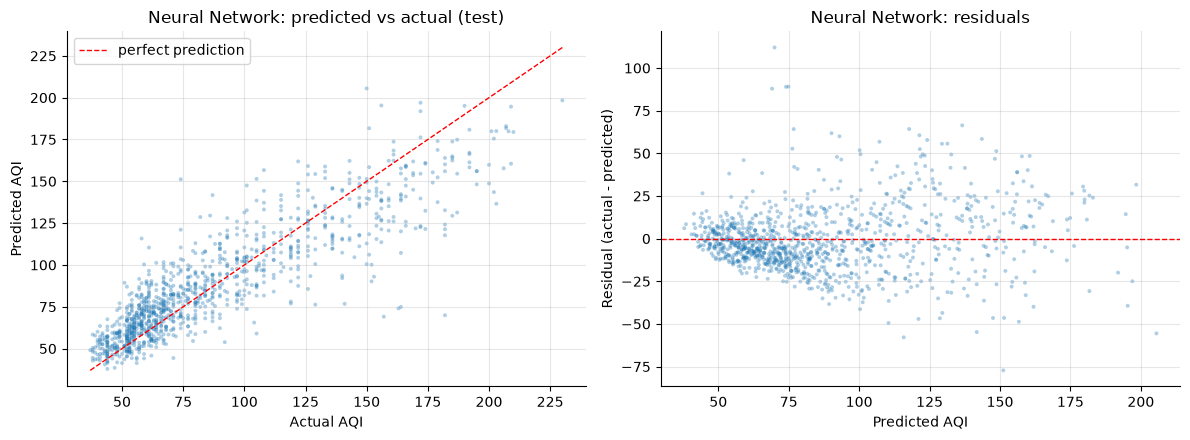

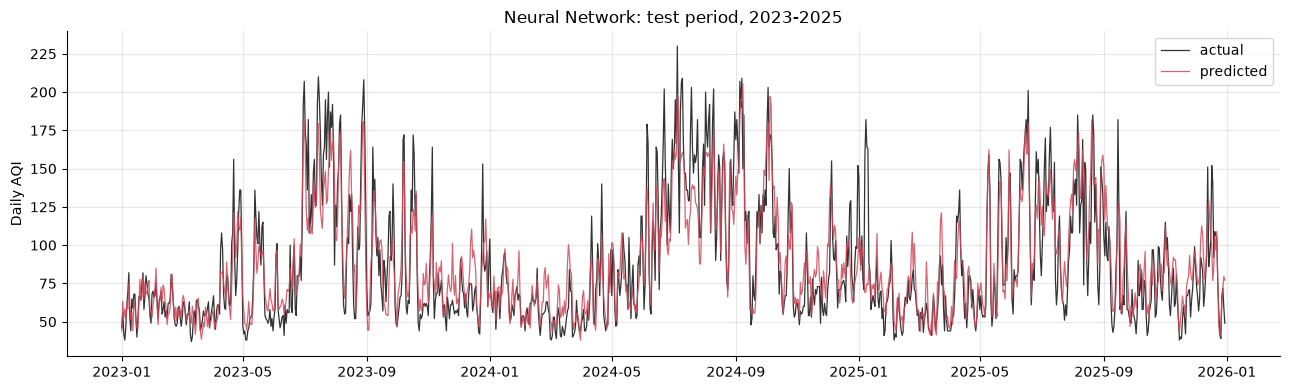

In [3]:
diagnostic_plots(MODEL_NAME, y_test, best.predict(X_test), meta['test_dates'])

## Did it converge, and how hard did it have to work?

Two things worth recording: whether early stopping fired well before the iteration
cap (it should have), and the size of the network that won. If the smallest
architecture in the grid came out on top, that is the search telling us the dataset
does not support a large model.

architecture:      (128, 64)
iterations run:    244 (cap was 1500)
alpha (L2):        0.1
final loss:        122.107

trainable parameters: 13,185
training days:        2,554
ratio:                5.2 parameters per training day


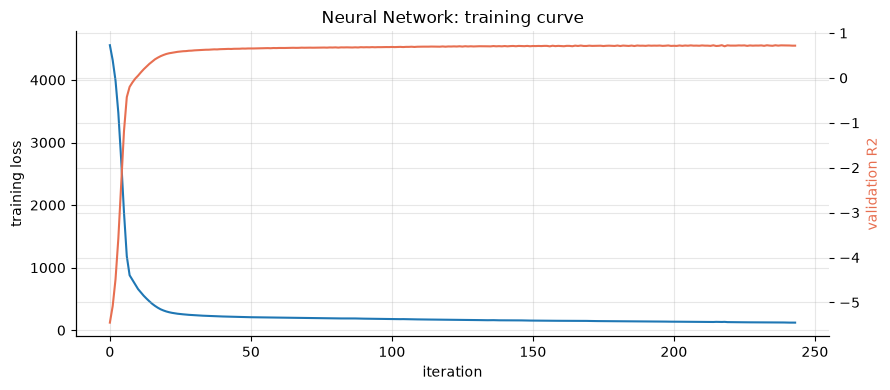

In [4]:
mlp = best.named_steps['model']
print(f'architecture:      {mlp.hidden_layer_sizes}')
print(f'iterations run:    {mlp.n_iter_} (cap was {mlp.max_iter})')
print(f'alpha (L2):        {mlp.alpha}')
print(f'final loss:        {mlp.loss_:.3f}')

n_params = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
print(f'\ntrainable parameters: {n_params:,}')
print(f'training days:        {len(X_train):,}')
print(f'ratio:                {n_params/len(X_train):.1f} parameters per training day')

with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(mlp.loss_curve_, label='training loss')
    if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
        ax2 = ax.twinx()
        ax2.plot(mlp.validation_scores_, color='#e76f51', label='validation R2')
        ax2.set_ylabel('validation R2', color='#e76f51')
    ax.set_xlabel('iteration'); ax.set_ylabel('training loss')
    ax.set_title('Neural Network: training curve')
    plt.tight_layout(); plt.show()

## What this told us

**Test RMSE 19.1, R² 0.777 — second best overall**, a hair behind SVR and ahead of
both tree models, with a similarly healthy overfit gap of **+2.2**.

The most informative result is what the search *chose*. `alpha=0.1` is the
strongest weight decay in the grid, and it won — cross-validation asked for maximum
regularization. Early stopping then halted training after 244 of a possible 1500
iterations. Both signals say the same thing: with 13,185 trainable parameters
against 2,554 training days (5.2 parameters per day), the network has far more
capacity than the data can support, and every guard against exploiting that
capacity was pulled tight.

The flexibility that makes an MLP a universal approximator is not an advantage at
this sample size. It lands in the same performance band as SVR — a model with a far
simpler inductive bias — and gets there only by being heavily constrained. Ten
years of daily data is roughly 3,600 rows; that is a tabular problem, not a deep
learning one.

The training curve shows smooth convergence with no instability, so this is a fair
representation of what an MLP can do here, not a failed fit.